In [3]:
import pandas as pd
df_clean = pd.read_csv('dataset/Antam_historical_gold_prices_clean.csv')
print(df_clean.columns)

Index(['Time (ms)', 'Gold Price', 'tanggal', 'hari_ke'], dtype='object')


In [4]:
from sklearn.model_selection import train_test_split

# Menggunakan nama kolom yang sesuai dengan hasil print tadi
X = df_clean[['hari_ke']]
y = df_clean['Gold Price']  # Menggunakan 'Gold Price' sebagai target

# Membagi data (80% latih, 20% uji)
# shuffle=False karena ini data time-series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Pembagian data berhasil!")
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Pembagian data berhasil!
Jumlah data latih: 1684
Jumlah data uji: 421


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor # <--- Tambahkan import ini
from sklearn.pipeline import make_pipeline

# 1. Model Regresi Linear
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

# 2. Model Regresi Polinomial (derajat 2)
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y_train)

# 3. Model Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 4. Model Decision Tree
model_dt = DecisionTreeRegressor(random_state=42) # <--- Tambahkan ini
model_dt.fit(X_train, y_train)

print("Keempat model telah berhasil dilatih!")

Keempat model telah berhasil dilatih!


In [6]:
from sklearn.metrics import r2_score

# Prediksi untuk keempat model
pred_linear = model_linear.predict(X_test)
pred_poly = model_poly.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_dt = model_dt.predict(X_test) # <--- Tambahkan ini

# Skor Evaluasi
print(f"Skor R2 Linear: {r2_score(y_test, pred_linear):.4f}")
print(f"Skor R2 Polinomial: {r2_score(y_test, pred_poly):.4f}")
print(f"Skor R2 Random Forest: {r2_score(y_test, pred_rf):.4f}")
print(f"Skor R2 Decision Tree: {r2_score(y_test, pred_dt):.4f}") # <--- Tambahkan ini

Skor R2 Linear: -4.3369
Skor R2 Polinomial: -0.5706
Skor R2 Random Forest: -1.7303
Skor R2 Decision Tree: -1.6841


In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Daftar model dan prediksinya
models_results = [
    ("Linear", pred_linear),
    ("Polinomial", pred_poly),
    ("Random Forest", pred_rf),
    ("Decision Tree", pred_dt)
]

# Menghitung metrik untuk setiap model
results = []
for name, pred in models_results:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])

# Membuat tabel agar mudah dilihat
df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(df_results)

           Model            MAE           RMSE        R2
0         Linear  558310.348001  604648.001779 -4.336901
1     Polinomial  286138.869026  328010.131862 -0.570574
2  Random Forest  347966.864608  432477.263513 -1.730301
3  Decision Tree  344339.667458  428800.578203 -1.684075


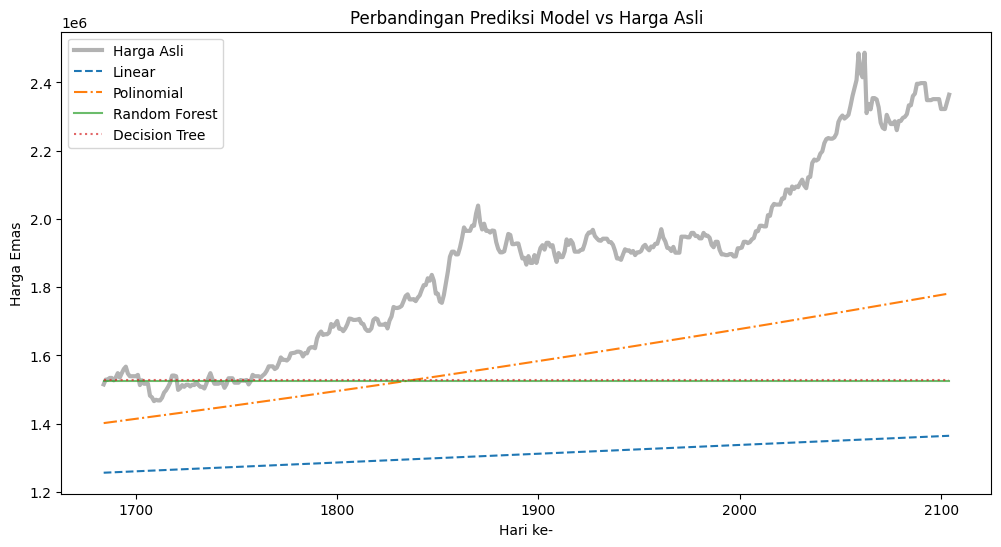

In [14]:
plt.figure(figsize=(12, 6))
# Plot Data Asli
plt.plot(X_test, y_test, label='Harga Asli', color='black', alpha=0.3, linewidth=3)

# Plot Model Regresi
plt.plot(X_test, pred_linear, label='Linear', linestyle='--')
plt.plot(X_test, pred_poly, label='Polinomial', linestyle='-.')

# Plot Model Pohon dengan style berbeda agar terlihat
plt.plot(X_test, pred_rf, label='Random Forest', linestyle='-', alpha=0.7)
plt.plot(X_test, pred_dt, label='Decision Tree', linestyle=':', alpha=0.7)

plt.title('Perbandingan Prediksi Model vs Harga Asli')
plt.xlabel('Hari ke-')
plt.ylabel('Harga Emas')
plt.legend()
plt.show()

In [12]:
import joblib

# Menyimpan keempat model ke folder 'models/'
joblib.dump(model_linear, 'models/model_linear.pkl')
joblib.dump(model_poly, 'models/model_poly.pkl')
joblib.dump(model_rf, 'models/model_rf.pkl')
joblib.dump(model_dt, 'models/model_dt.pkl')

print("Keempat model berhasil disimpan ke folder models/!")

Keempat model berhasil disimpan ke folder models/!
